Megan Englert
INFO 5653
Project Part 3


# Section 1: Data and Questions
Corpuses were built manually by creating .txt files in Notepad application.

# Section 2: Cleaning and Preparing the Data

In [157]:
import nltk
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
#Convert a collection of raw documents to a matrix of TF-IDF features.
#Equivalent to CountVectorizer but with tf-idf norm
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
## For Stemming
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import os



In [160]:
df = pd.read_csv("../combinedtextdata.csv").drop("Unnamed: 0", axis=1)
# making new df's in case anything weird happens :)
df1 = df.copy()
df2 = df.copy()
df1

,Source,Source Leaning,type,Combined
0,CNET,Center,news article,What Happens to Student Loans and Financial Ai...
1,Business Insider,Left-Center,news article,I took on almost K in debt to attend an Ivy Le...
2,Time,Not known,news article,Student Loans Still Available After White Hous...
3,Business Insider,Left-Center,news article,Student loans for millions of federal borrower...
4,Yahoo Entertainment,Not known,news article,People Say Their Student Loans Are Being Cance...
...,...,...,...,...
1311,Reddit,Not known,reddit comment,I have some sympathies for children who get in...
1312,Reddit,Not known,reddit comment,I am reading everything three times because no...
1313,Reddit,Not known,reddit comment,I did the same If they live on campus they can...
1314,Reddit,Not known,reddit comment,Youre right I should not have commented on the...


In [166]:
# Creating "Dataframe 1" -- All documents, using to predict type
df1 = df.copy()
df1labels = df1["type"]
contentList = [text for text in df1["Combined"]]
df1labels


0         news article
1         news article
2         news article
3         news article
4         news article
             ...      
1311    reddit comment
1312    reddit comment
1313    reddit comment
1314    reddit comment
1315    reddit comment
Name: type, Length: 1316, dtype: object

In [165]:
cv1=CountVectorizer(input='content', 
                        stop_words='english',
                        max_features=500)
df1cv = cv1.fit_transform(contentList)
df1cv


<1316x500 sparse matrix of type '<class 'numpy.int64'>'
	with 18647 stored elements in Compressed Sparse Row format>

In [179]:
columns = cv1.get_feature_names_out()
#print(len(columns))
matrix1 = pd.DataFrame(df1cv.toarray(), columns = columns)
newdf = pd.concat([df1labels, matrix1],axis=1)
newcols = list(columns)
newcols.insert(0, "dataType")
newdf.columns = newcols
matrix1 = newdf.copy()

matrix1

,dataType,able,absolutely,academic,access,according,actual,actually,add,address,...,worse,worth,wouldnt,www,yeah,year,years,yes,young,youre
0,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,news article,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,reddit comment,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1312,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1313,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1314,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,1


In [180]:

df1 = matrix1.copy()
cv2=CountVectorizer(input='content', 
                        stop_words='english',
                        max_features=100)
df2cv = cv2.fit_transform(contentList)
columns = cv2.get_feature_names_out()
print(columns)
newcols = list(columns)
newcols.insert(0, "dataType")
matrix2 = pd.DataFrame(df2cv.toarray(), columns = columns)
matrix2 = pd.concat([df1labels, matrix2],axis=1)
matrix2.columns = newcols
df2 = matrix2.copy().reset_index().drop("index", axis=1)


df2 = df1.loc[:, df2.columns]#.drop("LABEL", axis = 1)
df2

['actually' 'administration' 'aid' 'americans' 'average' 'benefit'
 'better' 'biden' 'borrowers' 'class' 'college' 'colleges' 'community'
 'cost' 'costs' 'country' 'debt' 'degree' 'degrees' 'department' 'did'
 'does' 'doesnt' 'dollars' 'don' 'donald' 'dont' 'economy' 'education'
 'federal' 'financial' 'forgiveness' 'free' 'freeze' 'funding' 'getting'
 'going' 'good' 'government' 'grants' 'help' 'high' 'higher' 'house'
 'idea' 'im' 'income' 'just' 'know' 'like' 'loan' 'loans' 'long' 'lot'
 'lower' 'make' 'making' 'middle' 'million' 'money' 'month' 'need' 'new'
 'paid' 'pay' 'paying' 'people' 'person' 'point' 'president' 'private'
 'problem' 'program' 'programs' 'public' 'really' 'right' 'said' 'school'
 'schools' 'spending' 'state' 'states' 'student' 'students' 'tax' 'taxes'
 'thats' 'think' 'time' 'trump' 'tuition' 'universities' 'university'
 'want' 'way' 'work' 'year' 'years' 'youre']


,dataType,actually,administration,aid,americans,average,benefit,better,biden,borrowers,...,trump,tuition,universities,university,want,way,work,year,years,youre
0,news article,0,1,3,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
1,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
2,news article,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,news article,0,1,1,0,0,0,0,0,3,...,4,0,0,0,0,0,0,0,0,0
4,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,reddit comment,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1312,reddit comment,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1313,reddit comment,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1314,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,1,0,3,1,1,2,0,1


In [128]:
'''# Creating "Dataframe 2" -- 100 Features
df2 = df.copy()
df2 = df2[df2["type"] == "news article"]
df2labels = df2["Source Leaning"]
contentList = [text for text in df2["Combined"]]

cv2=CountVectorizer(input='content', 
                        stop_words='english', max_features= 100
                        )
df2cv = cv2.fit_transform(contentList)
columns = cv2.get_feature_names_out()
print(columns)
matrix2 = pd.DataFrame(df2cv.toarray(), columns = columns)
matrix2 = pd.concat([df2labels, matrix2],axis=1)
matrix2 = matrix2.rename(columns={'label':"LABEL"})
limitedterms = matrix2.copy()

df2 = limitedterms.copy()
df2'''

['according' 'administration' 'affect' 'aid' 'americans' 'apply' 'biden'
 'borrowers' 'children' 'close' 'college' 'cost' 'court' 'credit' 'cuts'
 'daughter' 'debt' 'department' 'despite' 'donald' 'education' 'families'
 'federal' 'fees' 'financial' 'florida' 'forgiveness' 'free' 'freeze'
 'funding' 'getty' 'government' 'grants' 'help' 'high' 'higher' 'house'
 'illegal' 'images' 'impact' 'including' 'joe' 'just' 'know' 'lawmakers'
 'left' 'li' 'like' 'loan' 'loans' 'look' 'looking' 'low' 'make' 'million'
 'millions' 'monday' 'money' 'need' 'new' 'news' 'office' 'pause' 'pay'
 'people' 'plans' 'power' 'president' 'private' 'program' 'programs'
 'public' 'record' 'relief' 'repayment' 'republican' 'said' 'scholarship'
 'school' 'schools' 'spending' 'state' 'states' 'student' 'students'
 'supreme' 'tax' 'temporary' 'time' 'trump' 'tuition' 'university' 'used'
 'ways' 'week' 'white' 'won' 'wondering' 'year' 'years']


,Source Leaning,according,administration,affect,aid,americans,apply,biden,borrowers,children,...,tuition,university,used,ways,week,white,won,wondering,year,years
0,Center,0,1,1,3,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,Left-Center,0,0,0,0,0,0,0,0,0,...,0,2,1,0,0,0,0,0,0,0
2,Not known,0,0,0,1,0,2,0,0,0,...,0,0,2,0,2,3,0,2,0,0
3,Left-Center,0,1,0,1,0,0,0,3,0,...,0,0,0,0,0,0,2,0,0,0
4,Not known,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
249,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
250,Left-Center,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


# Section 4: Testing and Training Sets

In [136]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
#import pydotplus 
#import graphviz  
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay
testtraindf1 = df1.copy().drop_duplicates()
#testtraindf1 = testtraindf1[testtraindf1["LABEL"] == "news article"]
testtraindf1=testtraindf1.loc[:, ~testtraindf1.columns.duplicated()]

In [137]:

# I'm going to use stratification because it makes for better results :)
articles = testtraindf1[testtraindf1["dataType"] == "news article"]
comments = testtraindf1[testtraindf1["dataType"] == "reddit comment"]

positive_train1, positive_test1=train_test_split(articles,test_size=.30)
negative_train1, negative_test1=train_test_split(comments,test_size=.30)
trainDF1 = pd.concat([positive_train1, negative_train1])
testDF1 = pd.concat([positive_test1, negative_test1])
#print("The Training Data is\n", trainDF)
#print("The Testing Data is\n", testDF)

## Now remove the labels from the data - but keep and name the labels
trainLabels1 = trainDF1["dataType"]

## Remove the label from the dataset itself
trainDF1 = trainDF1.drop(["dataType"], axis=1)
print(trainDF1)

testLabels1 = testDF1["dataType"]
## Remove the label from the dataset itself
testDF1 = testDF1.drop(["dataType"], axis=1)


      able  absolutely  academic  access  according  actual  actually  add  \
126      0           0         0       0          0       0         0    0   
184      0           0         0       0          0       0         0    0   
200      0           0         0       0          0       0         0    0   
175      0           0         0       0          0       0         0    0   
120      0           0         0       0          0       0         0    0   
...    ...         ...       ...     ...        ...     ...       ...  ...   
821      1           0         0       0          0       0         0    0   
282      0           0         0       0          0       0         0    0   
743      0           0         0       0          0       0         0    0   
734      0           0         0       0          0       0         0    0   
1035     0           0         0       0          0       0         0    0   

      address  administration  ...  worse  worth  wouldnt  www 

In [138]:
df2

,dataType,dataType,actually,administration,aid,americans,average,benefit,better,biden,...,trump,tuition,universities,university,want,way,work,year,years,youre
0,news article,0,0,1,3,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
1,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
2,news article,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,news article,0,0,1,1,0,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
4,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,reddit comment,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1312,reddit comment,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1313,reddit comment,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1314,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,1,0,3,1,1,2,0,1


In [139]:
trainDF2

,actually,administration,aid,americans,average,benefit,better,biden,borrowers,class,...,trump,tuition,universities,university,want,way,work,year,years,youre
124,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
73,0,2,0,1,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0
157,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
31,0,1,0,0,0,0,0,0,2,0,...,2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
795,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
633,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [140]:

trainDF2 = trainDF1.loc[:, df2.columns[2:]].copy()
trainLabels2 = trainLabels1.copy()
testDF2 = testDF1.loc[:, df2.columns[2:]].copy()
testLabels2 = testLabels1.copy()

The Multinomial NB Model Prediction Probabilities are:
[[1.    0.   ]
 [1.    0.   ]
 [0.968 0.032]
 [0.107 0.893]
 [0.224 0.776]
 [0.05  0.95 ]
 [0.416 0.584]
 [0.396 0.604]
 [1.    0.   ]
 [1.    0.   ]
 [0.964 0.036]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.097 0.903]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.868 0.132]
 [0.843 0.157]
 [0.658 0.342]
 [0.998 0.002]
 [1.    0.   ]
 [0.996 0.004]
 [1.    0.   ]
 [0.995 0.005]
 [0.001 0.999]
 [1.    0.   ]
 [0.    1.   ]
 [1.    0.   ]
 [0.    1.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.12  0.88 ]
 [1.    0.   ]
 [0.932 0.068]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.004 0.996]
 [1.    0.   ]
 [0.72  0.28 ]
 [0.007 0.993]
 [0.001 0.999]
 [1.    0.   ]
 [1.    0.   ]
 [0.037 0.963]
 [1.    0.   ]
 [0.997 0.003]
 [0.338 0.662]
 [1.    0.   ]
 [0.97  0.03 ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.984 0.016]


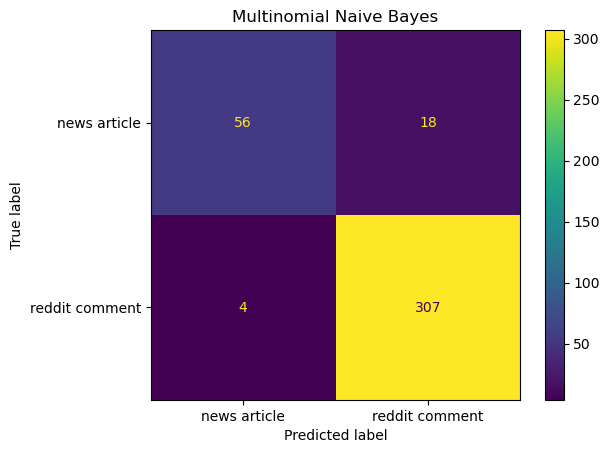

In [141]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
Training_MN = trainDF1.copy()
Testing_MN = testDF1.copy()
Training_MN_Label = trainLabels1.copy()
Testing_MN_Label = testLabels1.copy()

MyMN = MultinomialNB()
My_MN_Model = MyMN.fit(Training_MN, Training_MN_Label)
#print(My_MN_Model)
#print(My_MN_Model.classes_)

## Predict the Testing Data using the model
Predictions_MN=My_MN_Model.predict(Testing_MN)
#print(Predictions_MN)

## Print the actual probabilities
print("The Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_MN).round(3))

## Confusion Matrix
CM_MN = confusion_matrix(Testing_MN_Label, Predictions_MN)
print(CM_MN)
## Pretty confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=CM_MN,display_labels=My_MN_Model.classes_)
disp.plot()
plt.title("Multinomial Naive Bayes")
plt.show()

# Section 6: Decision Trees

In [193]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

trainDT = trainDF1.copy()
trainDTlabel = trainLabels1.copy()
testDT = testDF1.copy()
testDTlabel = testLabels1.copy()

MyDT_Classifier = DecisionTreeClassifier(criterion="gini", max_depth=4)
MyDT_Classifier = MyDT_Classifier.fit(trainDT, trainDTlabel)

FeatureNames=list(trainDT.columns.values) ## get all the feature/variable names
print(FeatureNames)
ClassNames=list(MyDT_Classifier.classes_) ## Get the class names
print(ClassNames)

plt.figure(figsize=(24,8))
##Tree Plot Option 1
MyPlot=tree.plot_tree(MyDT_Classifier,
                   feature_names=FeatureNames,  
                   class_names=ClassNames,
                   filled=True)
plt.title("Decision Tree for 500 features dataset")
plt.savefig("MyTree1.jpg",dpi=600)
plt.close()

## Use the Tree to make predictions
Prediction=MyDT_Classifier.predict(testDT)
print(Prediction)

Actual_Labels=testDTlabel
print(Actual_Labels)
Predicted_Labels=Prediction

My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

CM_disp=ConfusionMatrixDisplay(My_Conf_Mat, display_labels=MyDT_Classifier.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for Decision Tree for 500 features dataset")
plt.savefig("CM.jpg")
plt.close()


['able', 'absolutely', 'academic', 'access', 'according', 'actual', 'actually', 'add', 'address', 'administration', 'affect', 'afford', 'affordable', 'ago', 'agree', 'aid', 'allowed', 'america', 'american', 'americans', 'amounts', 'apply', 'arent', 'argument', 'arts', 'attend', 'available', 'average', 'away', 'bad', 'balance', 'bankruptcy', 'based', 'believe', 'benefit', 'benefits', 'best', 'better', 'biden', 'big', 'biggest', 'billion', 'bills', 'bit', 'board', 'books', 'borrowers', 'budget', 'building', 'burden', 'business', 'buy', 'buying', 'cap', 'car', 'care', 'career', 'case', 'cash', 'cc', 'certain', 'change', 'changes', 'changing', 'charge', 'cheaper', 'checks', 'children', 'choice', 'class', 'classes', 'close', 'college', 'colleges', 'com', 'come', 'comes', 'comments', 'community', 'companies', 'completely', 'congress', 'continue', 'control', 'cost', 'costs', 'countries', 'country', 'course', 'courses', 'court', 'cover', 'covid', 'created', 'credit', 'current', 'currently', 'c

In [198]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

trainDT = trainDF2.copy()
trainDTlabel = trainLabels2.copy()
testDT = testDF2.copy()
testDTlabel = testLabels2.copy()

MyDT_Classifier = DecisionTreeClassifier(max_depth=8,criterion='entropy')
MyDT_Classifier = MyDT_Classifier.fit(trainDT, trainDTlabel)

FeatureNames=list(trainDT.columns.values) ## get all the feature/variable names
print(FeatureNames)
ClassNames=list(MyDT_Classifier.classes_) ## Get the class names
print(ClassNames)

plt.figure(figsize=(10,4))
##Tree Plot Option 1
MyPlot=tree.plot_tree(MyDT_Classifier,
                   feature_names=FeatureNames,  
                   class_names=ClassNames,
                   filled=True)
plt.title("Decision Tree for Type Classification (100 Features)")
plt.savefig("MyTree2.jpg",dpi=600)
plt.close()

## Use the Tree to make predictions
Prediction=MyDT_Classifier.predict(testDT)
print(len(Prediction))

Actual_Labels=testLabels1
print(len(Actual_Labels))
Predicted_Labels=Prediction

My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

CM_disp=ConfusionMatrixDisplay(My_Conf_Mat, display_labels=MyDT_Classifier.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for Decision Tree Using Datafram 2 (100 Features)")
plt.savefig("CM2.jpg")
plt.close()

['actually', 'administration', 'aid', 'americans', 'average', 'benefit', 'better', 'biden', 'borrowers', 'class', 'college', 'colleges', 'community', 'cost', 'costs', 'country', 'debt', 'degree', 'degrees', 'department', 'did', 'does', 'doesnt', 'dollars', 'don', 'donald', 'dont', 'economy', 'education', 'federal', 'financial', 'forgiveness', 'free', 'freeze', 'funding', 'getting', 'going', 'good', 'government', 'grants', 'help', 'high', 'higher', 'house', 'idea', 'im', 'income', 'just', 'know', 'like', 'loan', 'loans', 'long', 'lot', 'lower', 'make', 'making', 'middle', 'million', 'money', 'month', 'need', 'new', 'paid', 'pay', 'paying', 'people', 'person', 'point', 'president', 'private', 'problem', 'program', 'programs', 'public', 'really', 'right', 'said', 'school', 'schools', 'spending', 'state', 'states', 'student', 'students', 'tax', 'taxes', 'thats', 'think', 'time', 'trump', 'tuition', 'universities', 'university', 'want', 'way', 'work', 'year', 'years', 'youre']
['news articl

# Section 7 - SVM

SVM 1 prediction:
 ['news article' 'news article' 'news article' 'news article'
 'news article' 'news article' 'reddit comment' 'news article'
 'news article' 'news article' 'news article' 'news article'
 'reddit comment' 'news article' 'news article' 'news article'
 'reddit comment' 'news article' 'news article' 'news article'
 'news article' 'reddit comment' 'news article' 'news article'
 'news article' 'news article' 'reddit comment' 'news article'
 'reddit comment' 'news article' 'reddit comment' 'news article'
 'reddit comment' 'news article' 'news article' 'reddit comment'
 'news article' 'news article' 'news article' 'news article'
 'news article' 'news article' 'news article' 'news article'
 'news article' 'news article' 'news article' 'reddit comment'
 'reddit comment' 'news article' 'news article' 'news article'
 'reddit comment' 'news article' 'news article' 'reddit comment'
 'news article' 'news article' 'news article' 'news article'
 'reddit comment' 'news article' 'news a

/Users/menglert/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


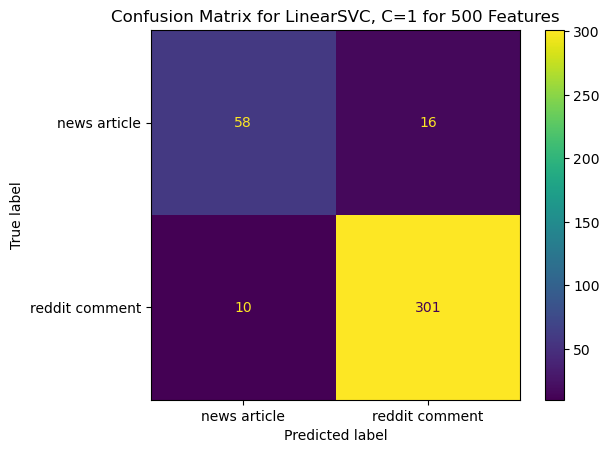

In [204]:
from sklearn.svm import LinearSVC


SVM_Model1=LinearSVC(C=1)

SVM_Model1.fit(trainDF1, trainLabels1)

print("SVM 1 prediction:\n", SVM_Model1.predict(testDF1))

SVM_matrix = confusion_matrix(testLabels1, SVM_Model1.predict(testDF1))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model1.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for LinearSVC, C=1 for 500 Features")
plt.show()
plt.close()



The confusion matrix for rbf SVM is:
[[ 56  18]
 [ 11 300]]





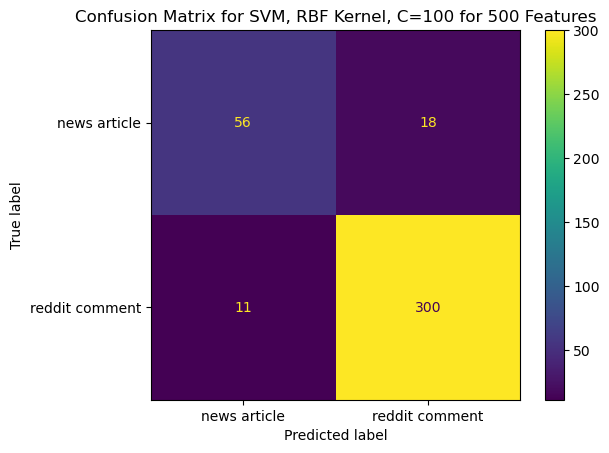

In [215]:
from sklearn.svm import SVC

SVM_Model2=SVC(C=100, kernel='rbf', gamma="auto")
SVM_Model2.fit(trainDF1, trainLabels1)

SVM_matrix = confusion_matrix(testLabels1, SVM_Model2.predict(testDF1))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model2.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, RBF Kernel, C=100 for 500 Features")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[  8  66]
 [  0 311]]





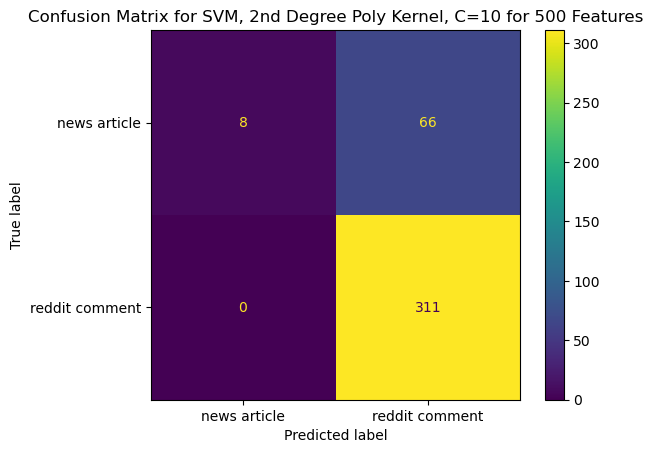

In [229]:
from sklearn.svm import SVC

# LOL the only way I can get it to do anything other than labelling them all as negative
# is to make the degree of the polynomial 1, but the instructions say not linear, so 
# I guess I am not doing that :)

SVM_Model3=SVC(C=10, kernel='poly', degree=2, gamma="auto")
SVM_Model3.fit(trainDF1, trainLabels1)

SVM_matrix = confusion_matrix(testLabels1, SVM_Model3.predict(testDF1))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model3.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, 2nd Degree Poly Kernel, C=10 for 500 Features")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[ 29  45]
 [  0 311]]





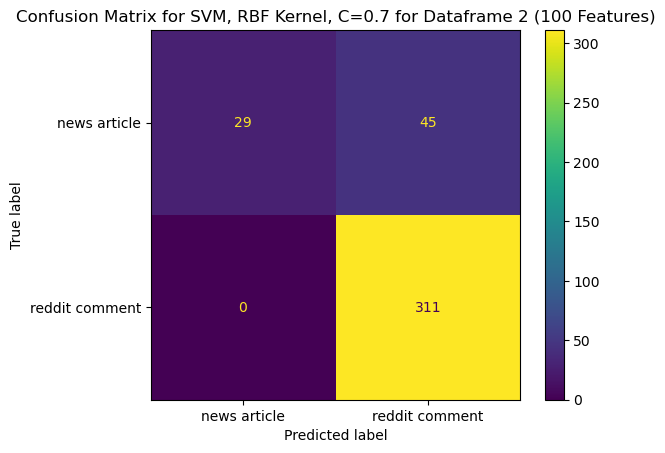

In [147]:
from sklearn.svm import SVC

SVM_Model2=SVC(C=0.7, kernel='rbf', gamma="auto")
SVM_Model2.fit(trainDF2, trainLabels2)

SVM_matrix = confusion_matrix(testLabels2, SVM_Model2.predict(testDF2))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model2.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, RBF Kernel, C=0.7 for Dataframe 2 (100 Features)")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[ 18  56]
 [  4 307]]





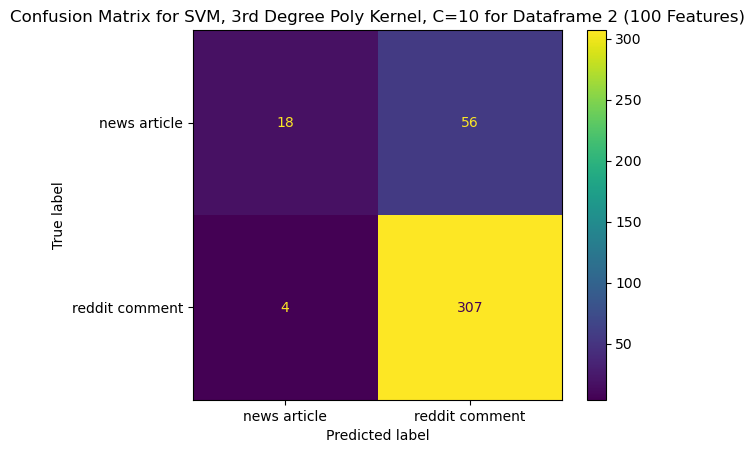

In [148]:
from sklearn.svm import SVC

SVM_Model3=SVC(C=10, kernel='poly', degree=3, gamma="auto")
SVM_Model3.fit(trainDF2, trainLabels2)

SVM_matrix = confusion_matrix(testLabels2, SVM_Model3.predict(testDF2))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model3.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, 3rd Degree Poly Kernel, C=10 for Dataframe 2 (100 Features)")
plt.show()
plt.close()

In [230]:
## Sentiment analysis
%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("That was awesome!")

  Obtaining dependency information for vaderSentiment from https://files.pythonhosted.org/packages/76/fc/310e16254683c1ed35eeb97386986d6c00bc29df17ce280aed64d55537e9/vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


{'neg': 0.0, 'neu': 0.313, 'pos': 0.687, 'compound': 0.6588}

In [233]:
sentDF = pd.read_csv("../combinedtextdata.csv")
sentDF = sentDF.drop(["Unnamed: 0", "Source", "Source Leaning", "type"], axis = 1)
sentDF

,Combined
0,What Happens to Student Loans and Financial Ai...
1,I took on almost K in debt to attend an Ivy Le...
2,Student Loans Still Available After White Hous...
3,Student loans for millions of federal borrower...
4,People Say Their Student Loans Are Being Cance...
...,...
1311,I have some sympathies for children who get in...
1312,I am reading everything three times because no...
1313,I did the same If they live on campus they can...
1314,Youre right I should not have commented on the...


In [234]:
def getSentiment(text: str) -> str:
    analyzer = SentimentIntensityAnalyzer()
    score = analyzer.polarity_scores(text)["compound"]
    if score < -0.25:
        return "negative"
    if score > 0.25:
        return "positive"
    return "neutral"

sentDF["VADER"] = sentDF["Combined"].apply(getSentiment)
sentDF

,Combined,VADER
0,What Happens to Student Loans and Financial Ai...,positive
1,I took on almost K in debt to attend an Ivy Le...,positive
2,Student Loans Still Available After White Hous...,positive
3,Student loans for millions of federal borrower...,positive
4,People Say Their Student Loans Are Being Cance...,neutral
...,...,...
1311,I have some sympathies for children who get in...,negative
1312,I am reading everything three times because no...,positive
1313,I did the same If they live on campus they can...,neutral
1314,Youre right I should not have commented on the...,positive


In [235]:
sentDF["VADER"].value_counts()

VADER
positive    647
negative    349
neutral     320
Name: count, dtype: int64

In [241]:
trainSentLabels = [sentDF["VADER"].loc[i] for i in list(trainDF1.index)]
testSentLabels = [sentDF["VADER"].loc[i] for i in list(testDF1.index)]
## Double checking that everything is correctly lining up :)
#trainDF1.head() # 126, 184, 200, 175, 120
#sentDF.loc[[126, 184, 200, 175, 120], :] # positive negative positive neutral neutral
testSentLabels # Yay, it is

['positive',
 'positive',
 'positive',
 'positive',
 'neutral',
 'negative',
 'neutral',
 'positive',
 'positive',
 'negative',
 'neutral',
 'positive',
 'negative',
 'positive',
 'neutral',
 'negative',
 'negative',
 'positive',
 'neutral',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'neutral',
 'neutral',
 'negative',
 'neutral',
 'positive',
 'neutral',
 'negative',
 'neutral',
 'neutral',
 'positive',
 'positive',
 'neutral',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'neutral',
 'positive',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'neutral',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'neutral',
 'negative',
 


The confusion matrix for rbf SVM is:
[[ 23  50  34]
 [ 11  65  25]
 [ 32  41 104]]





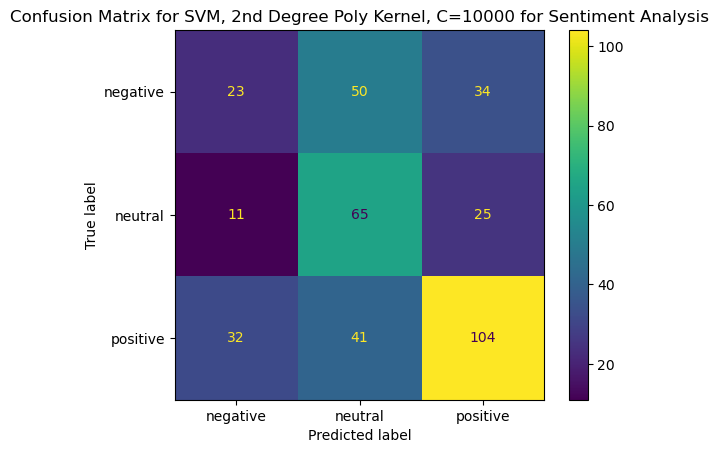

In [270]:
from sklearn.svm import SVC

# LOL the only way I can get it to do anything other than labelling them all as negative
# is to make the degree of the polynomial 1, but the instructions say not linear, so 
# I guess I am not doing that :)

SVM_Model3=SVC(C=10000, kernel='poly', degree=2, gamma="auto")
SVM_Model3.fit(trainDF1, trainSentLabels)

SVM_matrix = confusion_matrix(testSentLabels, SVM_Model3.predict(testDF1))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model3.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, 2nd Degree Poly Kernel, C=10000 for Sentiment Analysis")
plt.show()
plt.close()

SVM 1 prediction:
 ['positive' 'positive' 'positive' 'negative' 'negative' 'neutral'
 'positive' 'negative' 'positive' 'positive' 'positive' 'positive'
 'neutral' 'positive' 'negative' 'neutral' 'neutral' 'positive' 'positive'
 'positive' 'positive' 'positive' 'positive' 'positive' 'positive'
 'positive' 'neutral' 'negative' 'negative' 'positive' 'negative'
 'positive' 'positive' 'positive' 'positive' 'negative' 'positive'
 'negative' 'neutral' 'neutral' 'negative' 'positive' 'negative'
 'positive' 'positive' 'negative' 'negative' 'negative' 'positive'
 'positive' 'positive' 'positive' 'neutral' 'positive' 'negative'
 'positive' 'neutral' 'negative' 'positive' 'positive' 'neutral'
 'positive' 'positive' 'positive' 'neutral' 'positive' 'positive'
 'neutral' 'positive' 'positive' 'positive' 'positive' 'negative'
 'positive' 'neutral' 'negative' 'positive' 'neutral' 'neutral' 'negative'
 'neutral' 'neutral' 'positive' 'negative' 'positive' 'positive' 'neutral'
 'negative' 'positive' 'nega

/Users/menglert/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/menglert/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


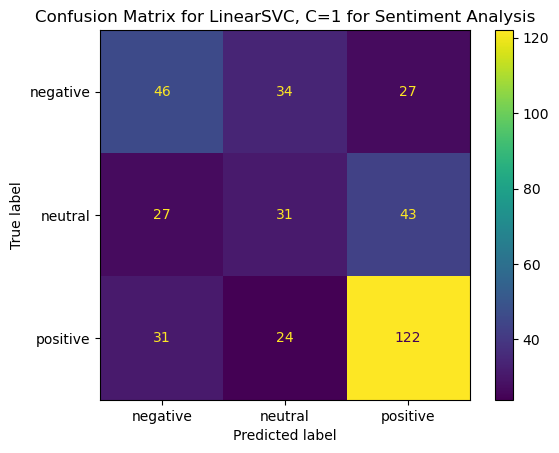

In [253]:
from sklearn.svm import LinearSVC


SVM_Model1=LinearSVC(C=1)

SVM_Model1.fit(trainDF1, trainSentLabels)

print("SVM 1 prediction:\n", SVM_Model1.predict(testDF1))

SVM_matrix = confusion_matrix(testSentLabels, SVM_Model1.predict(testDF1))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model1.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for LinearSVC, C=1 for Sentiment Analysis")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[ 30  30  47]
 [ 17  41  43]
 [ 34  21 122]]





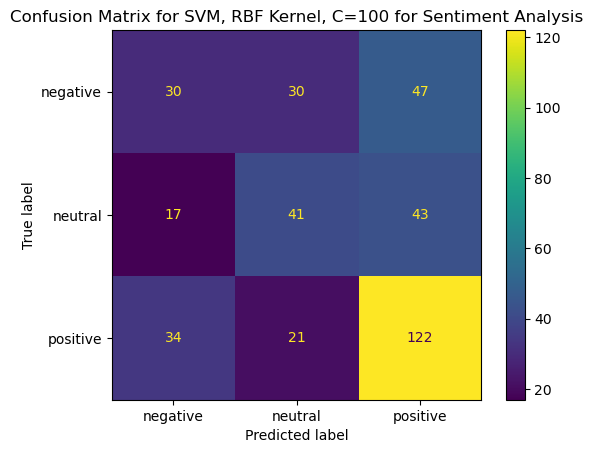

In [280]:
from sklearn.svm import SVC

SVM_Model2=SVC(C=100, kernel='rbf', gamma="auto")
SVM_Model2.fit(trainDF2, trainSentLabels)

SVM_matrix = confusion_matrix(testSentLabels, SVM_Model2.predict(testDF2))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model2.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, RBF Kernel, C=100 for Sentiment Analysis")
plt.show()
plt.close()